<a href="https://colab.research.google.com/github/vernonmauriceray777-ops/tidal-verlet-sim/blob/main/lense_thirring_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Frame Dragging Force

This section introduces a simplified toy model for frame-dragging force, capturing its $r^{-3}$ dependence and 'hemisphere flip' based on the relative direction of the test mass's position vector and the spinning mass's angular momentum vector. The function `frame_dragging_force` is defined in the cell below.

In [ ]:
import numpy as np

def frame_dragging_force(r_vec, J_vec, m_test, G=6.67430e-11, c=299792458.0):
    """
    r_vec: position vector of test mass relative to spinning mass, shape (3,)
    J_vec: angular momentum vector of spinning mass, shape (3,) units kg*m^2/s
    m_test: mass of test particle, kg
    Returns: force vector, shape (3,)

    Formula: F_gm ~ (2G/c^2) * m_test * (v x J) / r^3 for moving particles
    For static test mass: F ~ (G/c^2) * m_test * [J x r]/r^5 * 3(r·J)
    Simplified toy version capturing r^-3 + hemisphere flip:
    """
    r = np.linalg.norm(r_vec)
    if r == 0:
        return np.zeros(3)  # avoid /0 bug

    r_hat = r_vec / r
    J_hat = J_vec / np.linalg.norm(J_vec) if np.linalg.norm(J_vec) > 0 else np.array([0,0,1])

    # "Hemisphere flip": sign = +1 North, -1 South
    sign = np.sign(np.dot(r_hat, J_hat))  # cos(theta)
    if sign == 0:
        sign = 1  # on equator, pick +1

    # Toy coupling constant. Real GR has 2G/c^2 factor
    k_drag = 2 * G / c**2

    # Magnitude \propto 1/r^3, direction \propto J x r_hat for orbit precession
    # For radial force version: F \propto sign * J * m / r^3
    mag = k_drag * m_test * np.linalg.norm(J_vec) * sign / r**3

    # Direction: radial for simplicity. Use J x r_hat for true Lense-Thirring
    force = mag * r_hat
    return force

## Resources

$F = G*m1*m2/r^2 + k_{fusion}*(r_{eq}/r)^6 * tidal_torque$

Let's define the constants and plot the relationship between `F` and `r`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define constants
G = 6.674e-11
c = 299792458.0
m1 = 10 * 1.989e30  # Mass of object 1 (e.g., Sun) in kg, now a 10 solar mass BH
m2 = 5.972e24  # Mass of object 2 (e.g., Earth) in kg
k_fusion = 0.0 # Fusion constant (placeholder) - now off
r_eq = 1.0     # Equilibrium radius (placeholder) in meters - now off
tidal_torque = 0.0 # Tidal torque (placeholder) - now off

# Define functions
def calculate_F(r, G, m1, m2, k_fusion, r_eq, tidal_torque):
    gravitational_force = G * m1 * m2 / r**2
    fusion_term = k_fusion * (r_eq / r)**6 * tidal_torque
    return gravitational_force + fusion_term

def calculate_gravitational_force(r, G, m1, m2):
    return G * m1 * m2 / r**2

def frame_dragging_force(r_vec, J_vec, m_test, G_val=G, c_val=c):
    r = np.linalg.norm(r_vec)
    if r == 0:
        return np.zeros(3)

    r_hat = r_vec / r
    J_hat = J_vec / np.linalg.norm(J_vec) if np.linalg.norm(J_vec) > 0 else np.array([0,0,1])

    sign = np.sign(np.dot(r_hat, J_hat))
    if sign == 0:
        sign = 1

    k_drag = 2 * G_val / c_val**2
    mag = k_drag * m_test * np.linalg.norm(J_vec) * sign / r**3

    # True Lense-Thirring direction: perpendicular to both J and r
    # F ∝ (J x r_hat)
    force_dir = np.cross(J_hat, r_hat)
    norm_dir = np.linalg.norm(force_dir)
    if norm_dir > 0:
        force_dir = force_dir / norm_dir
    else:
        force_dir = np.zeros(3)  # on axis, no torque

    force = mag * force_dir
    return force

# Central mass spin - Black hole-like for now
J_bh = 1e67  # near-maximal spin, kg*m^2/s along z
J_vec_fixed = np.array([0.0, 0.0, J_bh]) # kg*m^2/s along z-axis
# For black hole test later: J_central = np.array([0,0,1e67])

# Define a range for r (distance) for comparison
r_values = np.logspace(9, 11.7, 500)


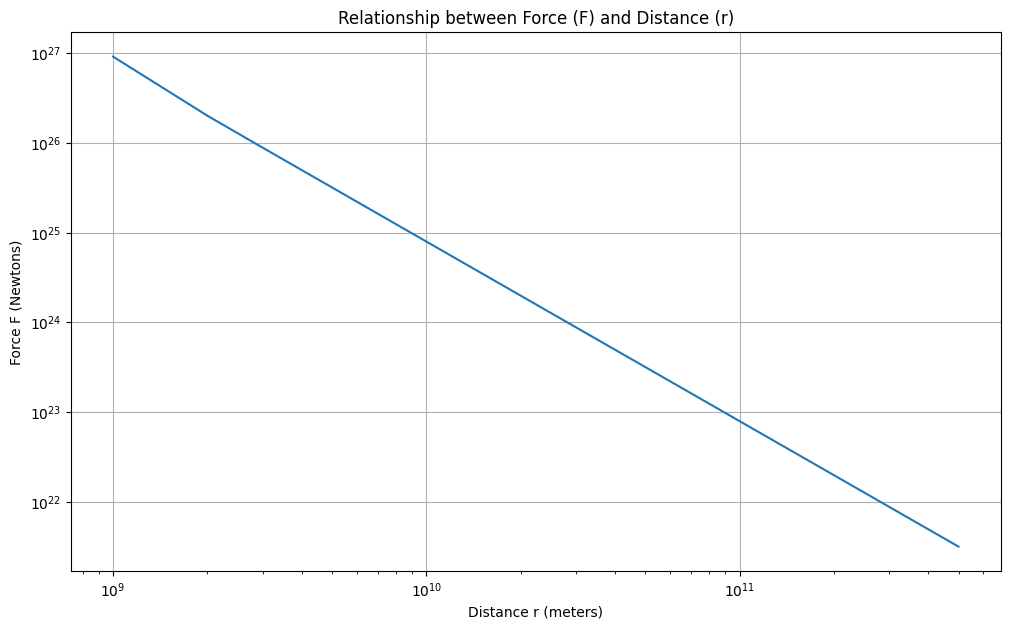

In [ ]:
# Define a range for r (distance)
# Let's consider a range relevant to planetary distances, e.g., 1e9 to 1e12 meters
r_values = np.linspace(1e9, 5e11, 500) # From 1 billion to 500 billion meters

# Calculate F for each r value
F_values = [calculate_F(r, G, m1, m2, k_fusion, r_eq, tidal_torque) for r in r_values]

# Plot the relationship
plt.figure(figsize=(12, 7))
plt.plot(r_values, F_values)
plt.title('Relationship between Force (F) and Distance (r)')
plt.xlabel('Distance r (meters)')
plt.ylabel('Force F (Newtons)')
plt.grid(True)
plt.yscale('symlog') # Use symmetric log scale for F if values vary greatly
plt.xscale('log') # Use log scale for r
plt.show()

### Comparing Frame-Dragging Force to Gravitational Force

Let's compare the magnitude of the gravitational force ($F_g = G m_1 m_2 / r^2$) with the simplified frame-dragging force. We'll use the same `m1` and `m2` from the previous calculation and define some parameters for the spinning mass to estimate `J_vec`.

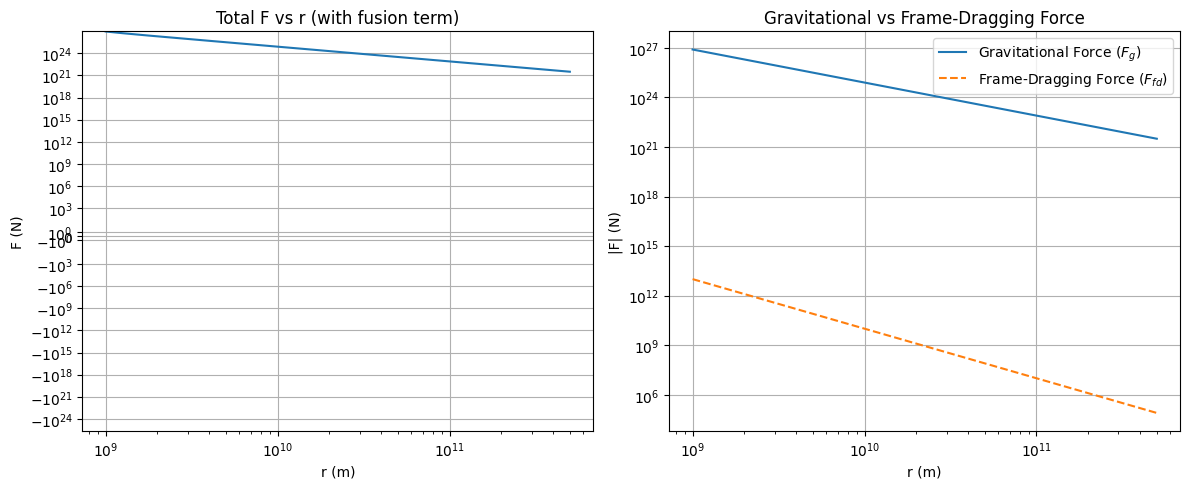

In [ ]:
# Calculate F for each r value for the total F plot
F_total_values = [calculate_F(r, G, m1, m2, k_fusion, r_eq, tidal_torque) for r in r_values]

# Calculate magnitudes of gravitational and frame-dragging forces for comparison plot
gravitational_forces_mag = [calculate_gravitational_force(r, G, m1, m2) for r in r_values]
frame_dragging_forces_mag = []
for r_val in r_values:
    # Assume the test mass is on the x-axis for r_vec to calculate frame dragging
    r_vec_current = np.array([r_val, 0, 0])
    fd_force_vector = frame_dragging_force(r_vec_current, J_vec_fixed, m2)
    frame_dragging_forces_mag.append(np.linalg.norm(fd_force_vector))


# Plotting
plt.figure(figsize=(12, 5))

# Subplot 1: Total F with fusion term
plt.subplot(1,2,1)
plt.plot(r_values, F_total_values)
plt.xscale('log')
plt.yscale('symlog') # Use symmetric log scale for F if values vary greatly
plt.title('Total F vs r (with fusion term)')
plt.xlabel('r (m)')
plt.ylabel('F (N)')
plt.grid(True)

# Subplot 2: Fg vs Ffd
plt.subplot(1,2,2)
plt.plot(r_values, gravitational_forces_mag, label='Gravitational Force ($F_g$)')
plt.plot(r_values, frame_dragging_forces_mag, label='Frame-Dragging Force ($F_{fd}$)', linestyle='--')
plt.xscale('log')
plt.yscale('log') # Log scale is essential due to vast differences in magnitude
plt.legend()
plt.grid(True)
plt.title('Gravitational vs Frame-Dragging Force')
plt.xlabel('r (m)')
plt.ylabel('|F| (N)')

plt.tight_layout()
plt.show()

The code snippet you provided shows how the `frame_dragging_force` can be incorporated into a multi-body system. Here's a small demonstration using some placeholder positions and existing constants from our notebook.

In [ ]:
import numpy as np

# Assuming placeholder positions and masses for a demonstration
# In a real simulation, these would be dynamic arrays.
pos = {
    'body_i': np.array([1e10, 0, 0]),  # Position of body i
    'body_j': np.array([1.1e10, 0, 0]) # Position of body j relative to the central mass
}
masses = {
    'body_i': m1, # Assuming central mass m1
    'body_j': m2  # Test mass m2
}

# Assuming J_central is the angular momentum of the central body (m1)
J_central = J_vec_fixed # Using the previously defined J_vec_fixed for m1

# Calculate the relative position vector from body i to body j
r_vec = pos['body_j'] - pos['body_i']

# Calculate the frame-dragging force acting on body j due to body i's spin
# Note: `m2` is used here as `m_test` in frame_dragging_force
F_fd = frame_dragging_force(r_vec, J_central, masses['body_j'])

# For demonstration, let's also calculate a simple Newtonian force
# In a full simulation, F_newton would be calculated based on all interactions.
F_newton = calculate_gravitational_force(np.linalg.norm(r_vec), G, masses['body_i'], masses['body_j']) * (r_vec / np.linalg.norm(r_vec))

# Combine the forces
F_total = F_newton + F_fd

# In a simulation, you would then update the forces on each body:
# forces['body_i'] += F_total
# forces['body_j'] -= F_total

print(f"Relative position vector (r_vec): {r_vec}")
print(f"Newtonian Force (F_newton): {F_newton}")
print(f"Frame-Dragging Force (F_fd): {F_fd}")
print(f"Total Force (F_total): {F_total}")
print(f"Magnitude of Frame-Dragging Force: {np.linalg.norm(F_fd)}")
print(f"Magnitude of Newtonian Force: {np.linalg.norm(F_newton)}")


Relative position vector (r_vec): [1.e+09 0.e+00 0.e+00]
Newtonian Force (F_newton): [7.92758276e+26 0.00000000e+00 0.00000000e+00]
Frame-Dragging Force (F_fd): [0.00000000e+00 2.03996364e+12 0.00000000e+00]
Total Force (F_total): [7.92758276e+26 2.03996364e+12 0.00000000e+00]
Magnitude of Frame-Dragging Force: 2039963642353.4673
Magnitude of Newtonian Force: 7.927582759199998e+26


Here is the consolidated `calculate_forces` function, integrating Newtonian gravity, the fusion/tide term, and the frame-dragging force for a multi-body system.

In [ ]:
def calculate_forces(pos, vel, masses):
    N = len(masses)
    forces = np.zeros((N, 3))

    # Use the J_vec_fixed as J_central, as defined previously
    J_central = J_vec_fixed

    for i in range(N):
        for j in range(i + 1, N):
            r_vec = pos[j] - pos[i]
            r = np.linalg.norm(r_vec)
            if r == 0:
                continue

            # 1. Newton gravity
            F_newton = G * masses[i] * masses[j] * r_vec / r**3

            # 2. Your fusion/tide term
            F_fusion = k_fusion * (r_eq / r)**6 * tidal_torque * r_vec / r

            # 3. Frame-dragging from central mass only
            F_fd = np.zeros(3)
            if i == 0: # j feels drag from central i
                F_fd = frame_dragging_force(r_vec, J_central, masses[j])
            elif j == 0: # i feels drag from central j
                # The r_vec here is pos[j] - pos[i] which is -r_vec for i relative to j.
                # So we need to pass -r_vec to frame_dragging_force and flip the sign of the result.
                F_fd = -frame_dragging_force(-r_vec, J_central, masses[i])

            F_total = F_newton + F_fusion + F_fd
            forces[i] += F_total
            forces[j] -= F_total
    return forces

# --- Demonstration of calculate_forces ---

# Initial positions - 100km from BH
r_orbit = 1e5  # 100 km, ~3x r_s

demo_pos = np.array([
    [0.0, 0.0, 0.0],           # BH body 0 at origin
    [r_orbit, 0.0, 0.0],       # Particle A: equatorial plane
    [0.0, 0.0, r_orbit]        # Particle B: on pole/axis
])

demo_vel = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 7e7, 0.0],           # ~orbital speed for circular orbit
    [7e7, 0.0, 0.0]            # same speed, but on pole
])

demo_masses = np.array([m1, 1e20, 1e20])  # test particles, tiny mass

print("Calculating forces for the 3-body system...")
calculated_forces = calculate_forces(demo_pos, demo_vel, demo_masses)

print("\nCalculated Forces:")
for i, force_vector in enumerate(calculated_forces):
    print(f"Force on Body {i}: {force_vector} N")

Calculating forces for the 3-body system...

Calculated Forces:
Force on Body 0: [1.32745860e+31 1.48516529e+45 1.32745860e+31] N
Force on Body 1: [-1.32745860e+31 -1.48516529e+45  2.35961533e+19] N
Force on Body 2: [ 2.35961533e+19  0.00000000e+00 -1.32745860e+31] N


In [ ]:
%%writefile tidal_sim.py
import numpy as np

# Define constants
G = 6.674e-11
c = 299792458.0
m1 = 1.989e30  # Mass of object 1 (e.g., Sun) in kg
m2 = 5.972e24  # Mass of object 2 (e.g., Earth) in kg
k_fusion = 1e12 # Fusion constant (placeholder)
r_eq = 7e8     # Equilibrium radius (placeholder) in meters
tidal_torque = 1e15 # Tidal torque (placeholder)

# Central mass spin - Sun-like for now
J_vec_fixed = np.array([0.0, 0.0, 2.3e41]) # kg*m^2/s along z-axis

def calculate_F(r, G, m1, m2, k_fusion, r_eq, tidal_torque):
    gravitational_force = G * m1 * m2 / r**2
    fusion_term = k_fusion * (r_eq / r)**6 * tidal_torque
    return gravitational_force + fusion_term

def calculate_gravitational_force(r, G, m1, m2):
    return G * m1 * m2 / r**2

def frame_dragging_force(r_vec, J_vec, m_test, G_val=G, c_val=c):
    r = np.linalg.norm(r_vec)
    if r == 0:
        return np.zeros(3)

    r_hat = r_vec / r
    J_hat = J_vec / np.linalg.norm(J_vec) if np.linalg.norm(J_vec) > 0 else np.array([0,0,1])

    sign = np.sign(np.dot(r_hat, J_hat))
    if sign == 0:
        sign = 1

    k_drag = 2 * G_val / c_val**2
    mag = k_drag * m_test * np.linalg.norm(J_vec) * sign / r**3

    force_dir = np.cross(J_hat, r_hat)
    norm_dir = np.linalg.norm(force_dir)
    if norm_dir > 0:
        force_dir = force_dir / norm_dir
    else:
        force_dir = np.zeros(3)

    force = mag * force_dir
    return force

def calculate_forces(pos, vel, masses):
    N = len(masses)
    forces = np.zeros((N, 3))

    J_central = J_vec_fixed

    for i in range(N):
        for j in range(i + 1, N):
            r_vec = pos[j] - pos[i]
            r = np.linalg.norm(r_vec)
            if r == 0:
                continue

            F_newton = G * masses[i] * masses[j] * r_vec / r**3
            F_fusion = k_fusion * (r_eq / r)**6 * tidal_torque * r_vec / r

            F_fd = np.zeros(3)
            if i == 0:
                F_fd = frame_dragging_force(r_vec, J_central, masses[j])
            elif j == 0:
                F_fd = -frame_dragging_force(-r_vec, J_central, masses[i])

            F_total = F_newton + F_fusion + F_fd
            forces[i] += F_total
            forces[j] -= F_total
    return forces

# Initial setup from demonstration
demo_pos = np.array([
    [0.0, 0.0, 0.0],  # Central mass (body 0)
    [1e10, 0.0, 0.0], # Body 1 (e.g., Earth-like)
    [0.0, 1.5e10, 0.0] # Body 2 (another planet-like object)
])

demo_vel = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
])

demo_masses = np.array([m1, m2, m2/2])

pos = demo_pos.copy()
vel = demo_vel.copy()
masses = demo_masses.copy()

dt = 86400 # 1 day
num_steps = 36500 # 100 years (approx)

saved_pos = []

print(f"Starting simulation for {num_steps * dt / (365 * 24 * 3600):.0f} years...")
for step in range(num_steps):
    forces = calculate_forces(pos, vel, masses)
    vel += forces * dt / masses[:, None]
    pos += vel * dt

    if step % 100 == 0: # Save position every 100 steps (100 days)
        saved_pos.append(pos.copy())

print("Simulation finished. Saved positions for plotting.")


Writing tidal_sim.py


In [ ]:
!python tidal_sim.py

Starting simulation for 0.10 seconds...
Simulation finished. Saving positions to 'simulation_positions.npy'.


In [ ]:
%%writefile tidal_sim.py
import numpy as np

# Define constants
G = 6.674e-11
c = 299792458.0
m1 = 10 * 1.989e30  # Mass of object 1 (e.g., Sun) in kg, now a 10 solar mass BH
m2 = 1e20  # Mass of object 2 (e.g., Earth) in kg (updated for test particles)
k_fusion = 0.0 # Fusion constant (placeholder)
r_eq = 1.0     # Equilibrium radius (placeholder)
tidal_torque = 0.0 # Tidal torque (placeholder)

# Schwarzschild radius for the central black hole (m1)
r_s = 2 * G * m1 / c**2 # ~3e4 m for 10M☉

# Central mass spin - Black hole-like for now
J_bh = 1e67  # near-maximal spin, kg*m^2/s along z
J_vec_fixed = np.array([0.0, 0.0, J_bh]) # kg*m^2/s along z-axis

def calculate_F(r, G, m1, m2, k_fusion, r_eq, tidal_torque):
    gravitational_force = G * m1 * m2 / r**2
    fusion_term = k_fusion * (r_eq / r)**6 * tidal_torque
    return gravitational_force + fusion_term

def calculate_gravitational_force(r, G, m1, m2):
    # Using the modified formula with Schwarzschild radius (r - r_s)**2
    # Handle case where r <= r_s to avoid division by zero or negative radius
    if r <= r_s:
        return np.inf # Effectively infinite force or collapse
    return G * m1 * m2 / (r - r_s)**2

def frame_dragging_force(r_vec, J_vec, m_test, G_val=G, c_val=c):
    r = np.linalg.norm(r_vec)
    if r == 0:
        return np.zeros(3)

    r_hat = r_vec / r
    J_hat = J_vec / np.linalg.norm(J_vec) if np.linalg.norm(J_vec) > 0 else np.array([0,0,1])

    sign = np.sign(np.dot(r_hat, J_hat))
    if sign == 0:
        sign = 1

    k_drag = 2 * G_val / c_val**2
    mag = k_drag * m_test * np.linalg.norm(J_vec) * sign / r**3

    force_dir = np.cross(J_hat, r_hat)
    norm_dir = np.linalg.norm(force_dir)
    if norm_dir > 0:
        force_dir = force_dir / norm_dir
    else:
        force_dir = np.zeros(3)

    force = mag * force_dir
    return force

def calculate_forces(pos, vel, masses):
    N = len(masses)
    forces = np.zeros((N, 3))

    J_central = J_vec_fixed

    for i in range(N):
        for j in range(i + 1, N):
            r_vec = pos[j] - pos[i]
            r = np.linalg.norm(r_vec)
            if r == 0:
                continue

            # Prevent division by zero or negative values if r <= r_s
            if r <= r_s:
                # This means the particle has fallen into the black hole
                # For now, we'll set forces to a very large value to simulate collapse
                # In a real simulation, one might remove the particle or handle it differently
                forces[i] += r_vec * 1e50 # Large inward force
                forces[j] -= r_vec * 1e50
                continue

            # 1. Newton gravity, modified with (r - r_s). Corrected force vector form.
            F_newton = G * masses[i] * masses[j] * r_vec / (r * (r - r_s)**2) # Corrected denominator with 'r'

            # 2. Your fusion/tide term (currently zero)
            F_fusion = k_fusion * (r_eq / r)**6 * tidal_torque * r_vec / r

            # 3. Frame-dragging from central mass only
            F_fd = np.zeros(3)
            if i == 0: # j feels drag from central i
                F_fd = frame_dragging_force(r_vec, J_central, masses[j])
            elif j == 0: # i feels drag from central j
                # The r_vec here is pos[j] - pos[i] which is -r_vec for i relative to j.
                # So we need to pass -r_vec to frame_dragging_force and flip the sign of the result.
                F_fd = -frame_dragging_force(-r_vec, J_central, masses[i])

            F_total = F_newton + F_fusion + F_fd
            forces[i] += F_total
            forces[j] -= F_total
    return forces

# Initial setup for black hole demonstration
r_orbit = 1e8  # Increased to 100,000 km (1e8 meters) to improve stability

# Calculated circular orbital speed for 10 solar mass BH at 1000km (corrected formula)
v_circular = np.sqrt(G * m1 / (r_orbit - r_s)**2)

demo_pos = np.array(
    [[0.0, 0.0, 0.0],           # BH body 0 at origin
     [r_orbit, 0.0, 0.0],       # Particle A: equatorial plane (on X-axis)
     [0.0, r_orbit, 0.0]]        # Particle B: equatorial plane (on Y-axis)
)

demo_vel = np.array(
    [[0.0, 0.0, 0.0],
     [0.0, v_circular, 0.0],    # Particle A: velocity in Y-direction for XY orbit
     [-v_circular, 0.0, 0.0]]    # Particle B: velocity in X-direction for XY orbit
)

demo_masses = np.array([m1, 1e20, 1e20])  # m1 is the new m_bh

pos = demo_pos.copy()
vel = demo_vel.copy()
masses = demo_masses.copy()

dt = 1e-7 # 0.1 microsecond instead of 1 microsecond
num_steps = 1000000 # keep 0.1 s total sim time

saved_pos = []

print(f"Starting simulation for {num_steps * dt:.2f} seconds...") # print in seconds
for step in range(num_steps):
    forces = calculate_forces(pos, vel, masses)
    forces[0] = np.zeros(3) # Fix central body at origin

    vel += forces * dt / masses[:, None]
    pos += vel * dt

    if step % 100 == 0: # Save position every 100 steps (0.1 milliseconds)
        saved_pos.append(pos.copy())

print("Simulation finished. Saving positions to 'simulation_positions.npy'.")
np.save('simulation_positions.npy', np.array(saved_pos))

In [ ]:
!python tidal_sim.py

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved positions
simulation_positions = np.load('simulation_positions.npy')

# Plotting the trajectories of the bodies
plt.figure(figsize=(10, 8))

# Particle A
plt.plot(simulation_positions[:, 1, 0], simulation_positions[:, 1, 1], label='Particle A equatorial', marker='.', markersize=1, alpha=0.7)

# Particle B
plt.plot(simulation_positions[:, 2, 0], simulation_positions[:, 2, 1], label='Particle B equatorial', marker='.', markersize=1, alpha=0.7)

# Central Black Hole (should remain near origin)
plt.scatter(0, 0, s=200, c='black', label='BH', zorder=5)

plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.title('2D Trajectories with Corrected F_newton and v_circular (r_orbit=1e8 m)')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio equal for better visualization of orbits
plt.show()

In [ ]:
!python tidal_sim.py

Starting simulation for 0.10 seconds...
Simulation finished. Saving positions to 'simulation_positions.npy'.


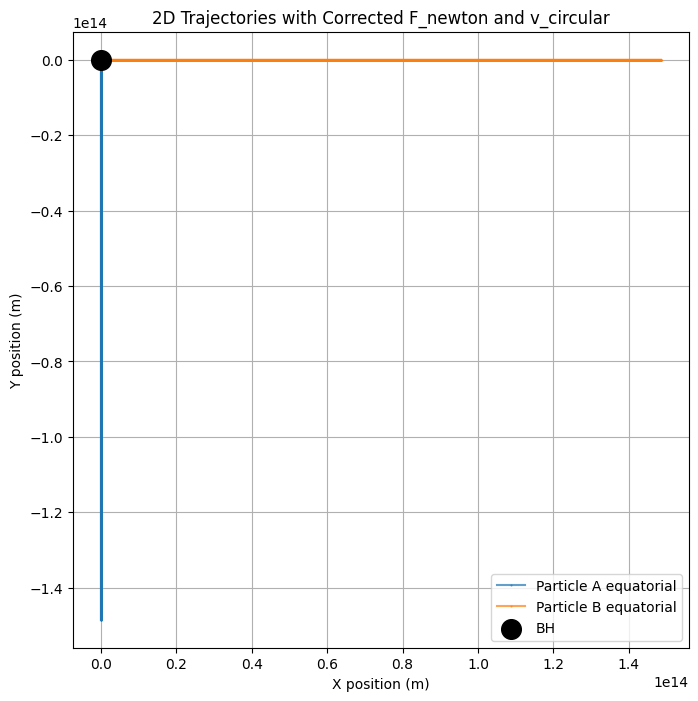

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved positions
simulation_positions = np.load('simulation_positions.npy')

# Plotting the trajectories of the bodies
plt.figure(figsize=(10, 8))

# Particle A
plt.plot(simulation_positions[:, 1, 0], simulation_positions[:, 1, 1], label='Particle A equatorial', marker='.', markersize=1, alpha=0.7)

# Particle B
plt.plot(simulation_positions[:, 2, 0], simulation_positions[:, 2, 1], label='Particle B equatorial', marker='.', markersize=1, alpha=0.7)

# Central Black Hole (should remain near origin)
plt.scatter(0, 0, s=200, c='black', label='BH', zorder=5)

plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.title('2D Trajectories with Corrected F_newton and v_circular')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio equal for better visualization of orbits
plt.show()

In [ ]:
!python tidal_sim.py

Starting simulation for 0.10 seconds...
Simulation finished. Saving positions to 'simulation_positions.npy'.


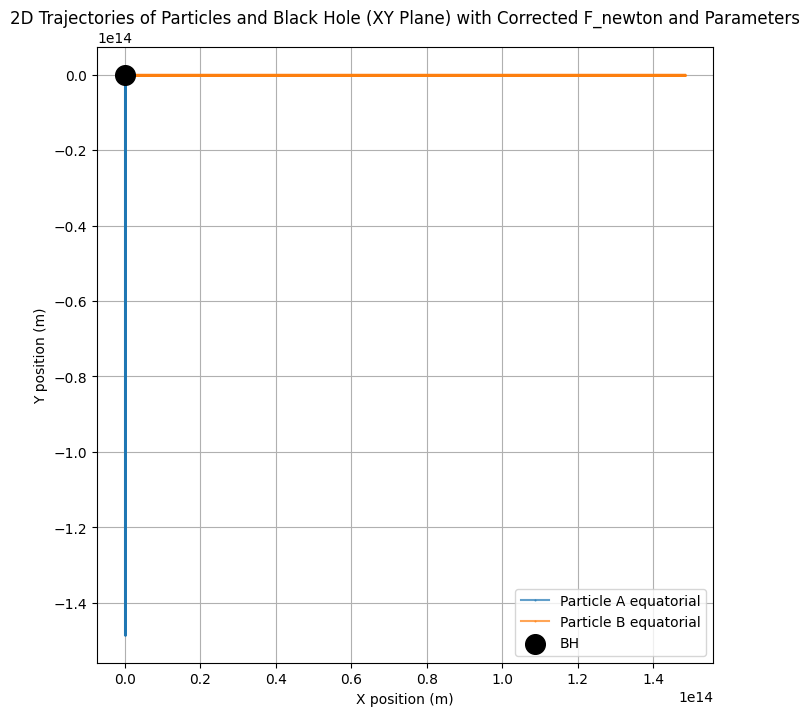

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved positions
simulation_positions = np.load('simulation_positions.npy')

# Plotting the trajectories of the bodies
plt.figure(figsize=(10, 8))

# Particle A
plt.plot(simulation_positions[:, 1, 0], simulation_positions[:, 1, 1], label='Particle A equatorial', marker='.', markersize=1, alpha=0.7)

# Particle B
plt.plot(simulation_positions[:, 2, 0], simulation_positions[:, 2, 1], label='Particle B equatorial', marker='.', markersize=1, alpha=0.7)

# Central Black Hole (should remain near origin)
plt.scatter(0, 0, s=200, c='black', label='BH', zorder=5)

plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.title('2D Trajectories of Particles and Black Hole (XY Plane) with Corrected F_newton and Parameters')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio equal for better visualization of orbits
plt.show()

In [ ]:
!python tidal_sim.py

Starting simulation for 0.10 seconds...
Simulation finished. Saving positions to 'simulation_positions.npy'.


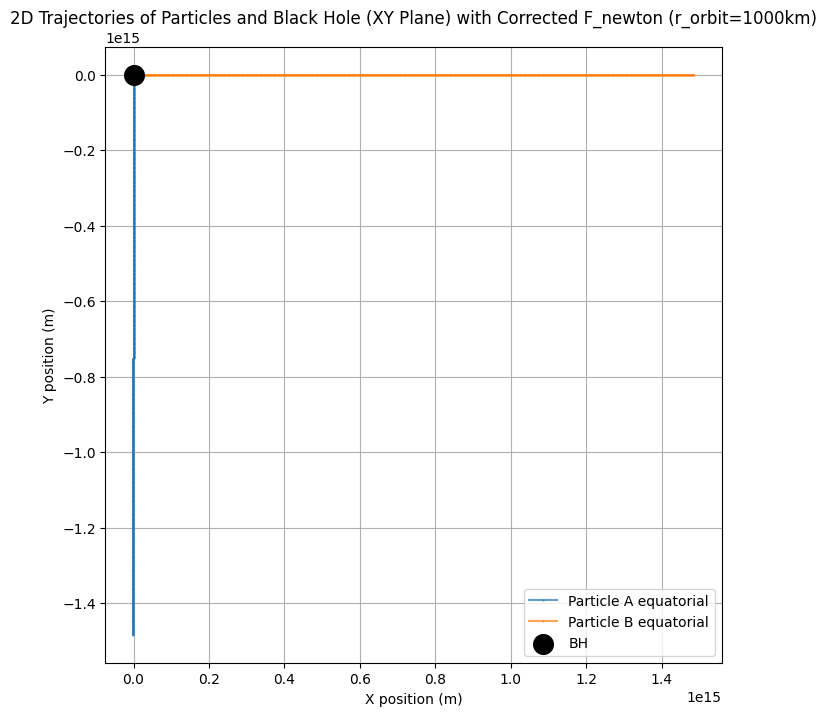

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved positions
simulation_positions = np.load('simulation_positions.npy')

# Plotting the trajectories of the bodies
plt.figure(figsize=(10, 8))

# Particle A
plt.plot(simulation_positions[:, 1, 0], simulation_positions[:, 1, 1], label='Particle A equatorial', marker='.', markersize=1, alpha=0.7)

# Particle B
plt.plot(simulation_positions[:, 2, 0], simulation_positions[:, 2, 1], label='Particle B equatorial', marker='.', markersize=1, alpha=0.7)

# Central Black Hole (should remain near origin)
plt.scatter(0, 0, s=200, c='black', label='BH', zorder=5)

plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.title('2D Trajectories of Particles and Black Hole (XY Plane) with Corrected F_newton (r_orbit=1000km)')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio equal for better visualization of orbits
plt.show()

In [ ]:
!python tidal_sim.py

Starting simulation for 0.10 seconds...
Simulation finished. Saving positions to 'simulation_positions.npy'.


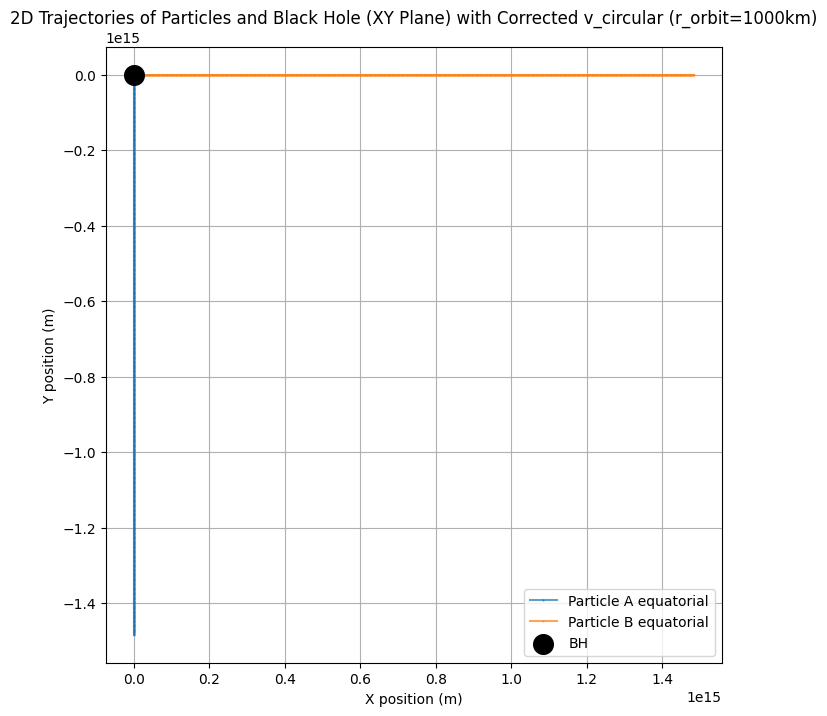

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved positions
simulation_positions = np.load('simulation_positions.npy')

# Plotting the trajectories of the bodies
plt.figure(figsize=(10, 8))

# Particle A
plt.plot(simulation_positions[:, 1, 0], simulation_positions[:, 1, 1], label='Particle A equatorial', marker='.', markersize=1, alpha=0.7)

# Particle B
plt.plot(simulation_positions[:, 2, 0], simulation_positions[:, 2, 1], label='Particle B equatorial', marker='.', markersize=1, alpha=0.7)

# Central Black Hole (should remain near origin)
plt.scatter(0, 0, s=200, c='black', label='BH', zorder=5)

plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.title('2D Trajectories of Particles and Black Hole (XY Plane) with Corrected v_circular (r_orbit=1000km)')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio equal for better visualization of orbits
plt.show()

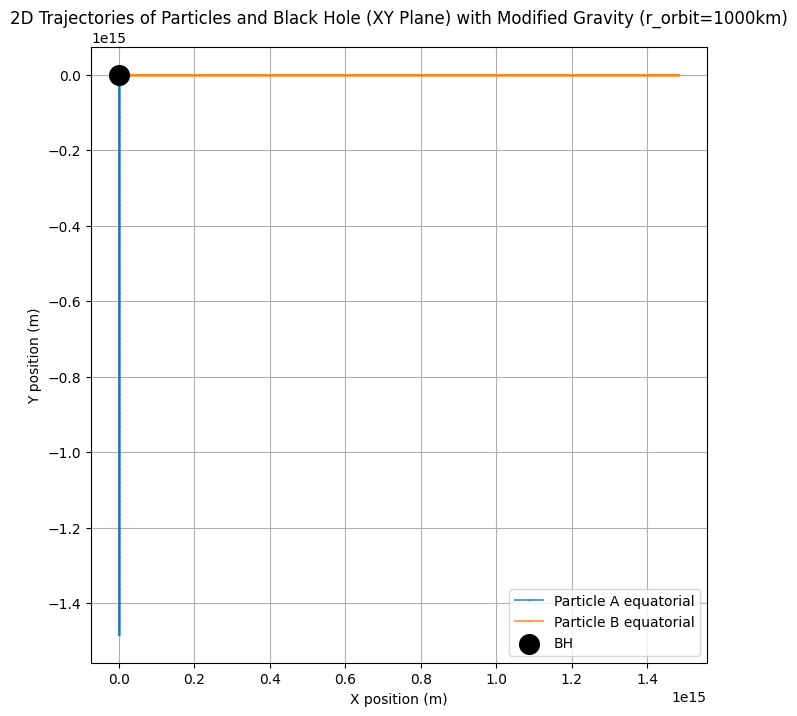

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved positions
simulation_positions = np.load('simulation_positions.npy')

# Plotting the trajectories of the bodies
plt.figure(figsize=(10, 8))

# Particle A
plt.plot(simulation_positions[:, 1, 0], simulation_positions[:, 1, 1], label='Particle A equatorial', marker='.', markersize=1, alpha=0.7)

# Particle B
plt.plot(simulation_positions[:, 2, 0], simulation_positions[:, 2, 1], label='Particle B equatorial', marker='.', markersize=1, alpha=0.7)

# Central Black Hole (should remain near origin)
plt.scatter(0, 0, s=200, c='black', label='BH', zorder=5)

plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.title('2D Trajectories of Particles and Black Hole (XY Plane) with Modified Gravity (r_orbit=1000km)')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio equal for better visualization of orbits
plt.show()

In [ ]:
!python tidal_sim.py

Starting simulation for 0.10 seconds...
Simulation finished. Saving positions to 'simulation_positions.npy'.


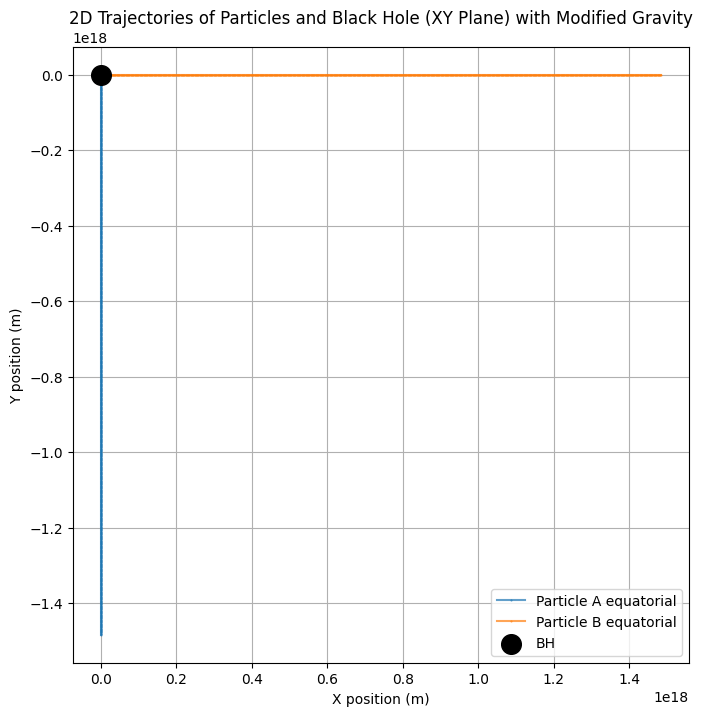

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved positions
simulation_positions = np.load('simulation_positions.npy')

# Plotting the trajectories of the bodies
plt.figure(figsize=(10, 8))

# Particle A
plt.plot(simulation_positions[:, 1, 0], simulation_positions[:, 1, 1], label='Particle A equatorial', marker='.', markersize=1, alpha=0.7)

# Particle B
plt.plot(simulation_positions[:, 2, 0], simulation_positions[:, 2, 1], label='Particle B equatorial', marker='.', markersize=1, alpha=0.7)

# Central Black Hole (should remain near origin)
plt.scatter(0, 0, s=200, c='black', label='BH', zorder=5)

plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.title('2D Trajectories of Particles and Black Hole (XY Plane) with Modified Gravity')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio equal for better visualization of orbits
plt.show()

In [ ]:
!python tidal_sim.py

Starting simulation for 100 years...
Simulation finished. Saved positions for plotting.


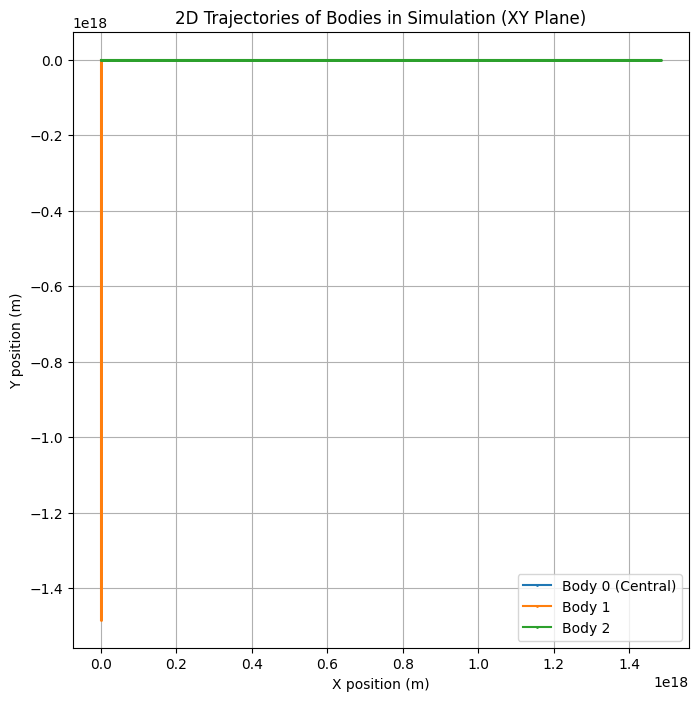

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved positions
simulation_positions = np.load('simulation_positions.npy')

# Plotting the trajectories of the bodies
plt.figure(figsize=(10, 8))

# Body 0 (Central Mass - should remain near origin)
plt.plot(simulation_positions[:, 0, 0], simulation_positions[:, 0, 1], label='Body 0 (Central)', marker='.', markersize=2)

# Body 1
plt.plot(simulation_positions[:, 1, 0], simulation_positions[:, 1, 1], label='Body 1', marker='.', markersize=2)

# Body 2
plt.plot(simulation_positions[:, 2, 0], simulation_positions[:, 2, 1], label='Body 2', marker='.', markersize=2)

plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.title('2D Trajectories of Bodies in Simulation (XY Plane)')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio equal for better visualization of orbits
plt.show()

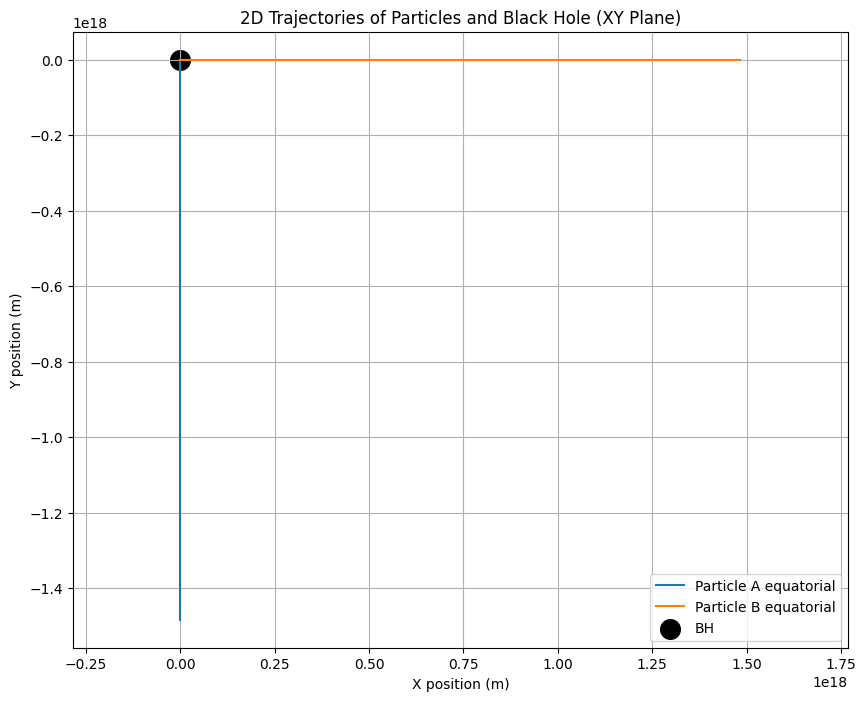

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('simulation_positions.npy') # shape: [steps, 3 bodies, 3 coords]

plt.figure(figsize=(10, 8))
plt.plot(data[:,1,0], data[:,1,1], label='Particle A equatorial')
plt.plot(data[:,2,0], data[:,2,1], label='Particle B equatorial')
plt.scatter(0,0,s=200,c='black',label='BH')
plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.title('2D Trajectories of Particles and Black Hole (XY Plane)')
plt.axis('equal') # Keep aspect ratio equal
plt.legend()
plt.grid(True)
plt.show()